In [ ]:
#task1 A

In [ ]:
from pathlib import Path
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import librosa
import librosa.display

In [ ]:
DATASET_PATH = Path(r"data\ravdess")

wav_files = list(DATASET_PATH.rglob("*.wav"))

print("Dataset exists:", DATASET_PATH.exists())
print("Total WAV files found:", len(wav_files))



In [ ]:
def parse_ravdess_filename(path: str) -> dict:
    filename = Path(path).name
    parts = filename.replace(".wav", "").split("-")

    modality_map = {
        "01": "full-AV",
        "02": "video-only",
        "03": "audio-only"
    }

    vocal_channel_map = {
        "01": "speech",
        "02": "song"
    }

    emotion_map = {
        "01": "neutral",
        "02": "calm",
        "03": "happy",
        "04": "sad",
        "05": "angry",
        "06": "fearful",
        "07": "disgust",
        "08": "surprised"
    }

    intensity_map = {
        "01": "normal",
        "02": "strong"
    }

    statement_map = {
        "01": "kids are talking",
        "02": "dogs are sitting"
    }

    repetition_map = {
        "01": "first",
        "02": "second"
    }

    return {
        "modality": modality_map.get(parts[0]),
        "vocal_channel": vocal_channel_map.get(parts[1]),
        "emotion": emotion_map.get(parts[2]),
        "intensity": intensity_map.get(parts[3]),
        "statement": statement_map.get(parts[4]),
        "repetition": repetition_map.get(parts[5]),
        "actor": f"Actor_{parts[6]}"
    }

In [ ]:
parse_ravdess_filename("03-01-05-01-01-01-24.wav")

In [ ]:
#task 1 B

In [ ]:
emotion_rows = []

for path in wav_files:
    parts = path.stem.split("-")

    if len(parts) == 7:
        info = parse_ravdess_filename(str(path))
        emotion_rows.append(info["emotion"])

df_emotions = pd.DataFrame(emotion_rows, columns=["emotion"])

counts = df_emotions["emotion"].value_counts()


In [ ]:
plt.figure(figsize=(8, 5))
counts.plot(kind="bar")
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Files")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
durations = []

for path in wav_files:
    parts = path.stem.split("-")

    if len(parts) == 7:
        try:
            y, sr = librosa.load(str(path), sr=None)
            duration = len(y) / sr
            durations.append(duration)
        except Exception as e:
            print("Skipped:", path.name, "| Error:", e)

durations = np.array(durations)



In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(durations, bins=20)
plt.title("Audio Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Files")
plt.tight_layout()
plt.show()

In [ ]:
samples = {
    "happy": None,
    "sad": None,
    "angry": None
}

for path in wav_files:
    parts = path.stem.split("-")

    if len(parts) == 7:
        info = parse_ravdess_filename(str(path))
        emotion = info["emotion"]

        if emotion in samples and samples[emotion] is None:
            samples[emotion] = path

print("Selected samples:")
for emotion, path in samples.items():
    print(emotion, "=>", path)

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(12, 10))

for i, (emotion, path) in enumerate(samples.items()):
    y, sr = librosa.load(str(path), sr=None)

    ax[i, 0].plot(y)
    ax[i, 0].set_title(f"{emotion} - Waveform")
    ax[i, 0].set_xlabel("Samples")
    ax[i, 0].set_ylabel("Amplitude")

    S = librosa.feature.melspectrogram(y=y, sr=sr)
    S_db = librosa.power_to_db(S, ref=np.max)

    librosa.display.specshow(
        S_db,
        sr=sr,
        x_axis="time",
        y_axis="mel",
        ax=ax[i, 1]
    )

    ax[i, 1].set_title(f"{emotion} - Mel Spectrogram")

plt.tight_layout()
plt.show()

In [ ]:
#task 2 A

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import opensmile
import seaborn as sns

In [ ]:
smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals,
)

In [ ]:
file_path = "data/ravdess/Actor_01/03-01-03-01-01-01-01.wav"

In [ ]:
features = smile.process_file(file_path)

In [ ]:
print(features.shape)

In [ ]:
print(features.columns.tolist())

In [ ]:
print(features.values)

In [ ]:
#task2 B

In [ ]:
import os
import pandas as pd
import opensmile

In [ ]:
smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals,
)

In [ ]:
DATASET_PATH = "data/ravdess"

In [ ]:
from tqdm import tqdm

rows = []

for root, _, files in os.walk(DATASET_PATH):
    for f in tqdm(files):
        if f.endswith(".wav"):
            path = os.path.join(root, f)
            
            feat = smile.process_file(path)
            emotion = f.split("-")[2]
            feat["label"] = emotion
            
            rows.append(feat)

In [ ]:
df = pd.concat(rows).reset_index(drop=True)

In [ ]:
print(df.shape)

In [ ]:
df.to_csv("ravdess_egemaps.csv", index=False)
print("Saved ✅")

In [ ]:
#task 2 C

In [ ]:
df = pd.read_csv("ravdess_egemaps.csv")

In [ ]:
pitch_feature = "F0semitoneFrom27.5Hz_sma3nz_amean"

mean_pitch = df.groupby("label")[pitch_feature].mean()

mean_pitch

In [ ]:
mean_pitch.sort_values().plot(kind="barh")
plt.title("Mean Pitch per Emotion")
plt.xlabel("Pitch (mean)")
plt.ylabel("Emotion")
plt.show()

In [ ]:
corr = df.drop("label", axis=1).corr()

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
import numpy as np

corr_pairs = corr.abs().unstack()

# Remove self-correlations
corr_pairs = corr_pairs[corr_pairs < 1]

# Select strong ones
high_corr = corr_pairs[corr_pairs > 0.9]

high_corr.sort_values(ascending=False).head(10)

In [ ]:
#task3 A

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
df = pd.read_csv("ravdess_egemaps.csv")

print(df.shape)
df.head()

In [ ]:
X = df.drop(columns=["label", "file"], errors="ignore")
y = df["label"]

X = X.fillna(0)

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
min_class_count = y.value_counts().min()

n_splits = min(10, min_class_count)

print("Using n_splits =", n_splits)

cv = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

In [ ]:
print("Dataset shape:", df.shape)
print(y.value_counts())
print("Minimum"), "samples per class:", y.value_counts().min()

In [ ]:
svm = SVC(kernel="rbf", C=1.0)

svm_acc_scores = cross_val_score(
    svm,
    X_scaled,
    y,
    cv=cv,
    scoring="accuracy"
)

svm_uar_scores = cross_val_score(
    svm,
    X_scaled,
    y,
    cv=cv,
    scoring="balanced_accuracy"
)

print("SVM Mean Accuracy:", svm_acc_scores.mean())
print("SVM Accuracy Std:", svm_acc_scores.std())

print("SVM Mean UAR:", svm_uar_scores.mean())
print("SVM UAR Std:", svm_uar_scores.std())

In [ ]:
svm_cv_pred = cross_val_predict(
    svm,
    X_scaled,
    y,
    cv=cv
)

labels = sorted(y.unique())

cm = confusion_matrix(
    y,
    svm_cv_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax)
plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()


In [ ]:
svm_c_results = []

for C_val in [0.1, 1, 10]:
    svm_temp = SVC(kernel="rbf", C=C_val)

    scores = cross_val_score(
        svm_temp,
        X_scaled,
        y,
        cv=cv,
        scoring="balanced_accuracy"
    )

    svm_c_results.append({
        "C": C_val,
        "Mean UAR": scores.mean(),
        "UAR Std": scores.std()
    })

svm_c_results_df = pd.DataFrame(svm_c_results)
svm_c_results_df

In [ ]:
#task 3 B

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_acc_scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

rf_uar_scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="balanced_accuracy"
)

print("Random Forest Mean Accuracy:", rf_acc_scores.mean())
print("Random Forest Accuracy Std:", rf_acc_scores.std())

print("Random Forest Mean UAR:", rf_uar_scores.mean())
print("Random Forest UAR Std:", rf_uar_scores.std())

In [ ]:
rf.fit(X, y)

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(20)

In [ ]:
def feature_group(feature_name):
    name = feature_name.lower()

    if "f0" in name or "pitch" in name:
        return "pitch"
    elif "loudness" in name or "energy" in name or "rms" in name:
        return "energy"
    elif "mfcc" in name:
        return "mfcc"
    elif "spectral" in name or "alpha" in name or "hammarberg" in name:
        return "spectral"
    else:
        return "other"


color_map = {
    "pitch": "tab:blue",
    "energy": "tab:orange",
    "mfcc": "tab:green",
    "spectral": "tab:red",
    "other": "tab:gray"
}

In [ ]:
import matplotlib.patches as mpatches

legend_handles = [
    mpatches.Patch(color=color, label=group)
    for group, color in color_map.items()
]




In [ ]:
rf.fit(X, y)

importances = rf.feature_importances_
feature_names = X.columns

feature_importance = pd.Series(importances, index=feature_names)
top20 = feature_importance.nlargest(20).sort_values()

In [ ]:
def feature_group(name):
    name = name.lower()

    if "f0" in name or "pitch" in name:
        return "pitch"
    elif "loudness" in name or "energy" in name:
        return "energy"
    elif "mfcc" in name:
        return "mfcc"
    else:
        return "other"

color_map = {
    "pitch": "blue",
    "energy": "orange",
    "mfcc": "green",
    "other": "gray"
}

colors = [color_map[feature_group(f)] for f in top20.index]

plt.figure(figsize=(10, 7))
plt.barh(top20.index, top20.values, color=colors)
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
#task 3 C

In [ ]:
comparison = pd.DataFrame({
    "Model": ["SVM (RBF)", "Random Forest"],
    "Features": ["eGeMAPS", "eGeMAPS"],
    "Mean Acc.": [svm_acc_scores.mean(), rf_acc_scores.mean()],
    "Mean UAR": [svm_uar_scores.mean(), rf_uar_scores.mean()],
    "UAR Std": [svm_uar_scores.std(), rf_uar_scores.std()]
})

comparison

In [ ]:
comparison_rounded = comparison.copy()

for col in ["Mean Acc.", "Mean UAR", "UAR Std"]:
    comparison_rounded[col] = comparison_rounded[col].round(4)

comparison_rounded

In [ ]:
#task 4

In [ ]:
#part A

In [ ]:
import umap
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ravdess_egemaps.csv")

X = df.drop(columns=["label", "file"], errors="ignore").values
y = df["label"].values

In [ ]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

embedding = reducer.fit_transform(X)

print(embedding.shape)

In [ ]:
plt.figure(figsize=(8, 6))

for label in set(y):
    idx = (y == label)
    plt.scatter(
        embedding[idx, 0],
        embedding[idx, 1],
        label=label
    )

plt.title("UMAP 2D Projection (Emotion Clusters)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.show()


In [ ]:
neighbors_list = [5, 15, 30]

plt.figure(figsize=(15, 4))

for i, n in enumerate(neighbors_list):
    reducer = umap.UMAP(
        n_neighbors=n,
        min_dist=0.1,
        random_state=42
    )

    emb = reducer.fit_transform(X)

    plt.subplot(1, 3, i+1)
    
    for label in set(y):
        idx = (y == label)
        plt.scatter(
            emb[idx, 0],
            emb[idx, 1]
        )

    plt.title(f"n_neighbors={n}")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")

plt.tight_layout()
plt.show()

In [ ]:
#part B

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
reducer_raw = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

embedding_raw = reducer_raw.fit_transform(X)

In [ ]:
reducer_scaled = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

embedding_scaled = reducer_scaled.fit_transform(X_scaled)


In [ ]:
plt.figure(figsize=(12, 5))

# RAW
plt.subplot(1, 2, 1)
for label in set(y):
    idx = (y == label)
    plt.scatter(
        embedding_raw[idx, 0],
        embedding_raw[idx, 1]
    )
plt.title("UMAP (Raw Features)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

# SCALED
plt.subplot(1, 2, 2)
for label in set(y):
    idx = (y == label)
    plt.scatter(
        embedding_scaled[idx, 0],
        embedding_scaled[idx, 1]
    )
plt.title("UMAP (Standardised Features)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.tight_layout()
plt.show()

In [ ]:
#Task 5

In [ ]:
#part A

In [3]:
import torch
import torchaudio.transforms as T
import librosa

from torch.utils.data import Dataset, DataLoader
from pathlib import Path


In [4]:
class RAVDESSDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels

        self.target_sr = 22050

        self.mel = T.MelSpectrogram(
            sample_rate=self.target_sr,
            n_mels=64
        )

        self.db = T.AmplitudeToDB()

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        waveform, sr = librosa.load(path, sr=None, mono=True)

        if sr != self.target_sr:
            waveform = librosa.resample(waveform, orig_sr=sr, target_sr=self.target_sr)

        waveform = torch.tensor(waveform, dtype=torch.float32).unsqueeze(0)

        mel = self.mel(waveform)
        mel = self.db(mel)

        # Fix time dimension to 128
        if mel.shape[2] < 128:
            pad = 128 - mel.shape[2]
            mel = torch.nn.functional.pad(mel, (0, pad))
        else:
            mel = mel[:, :, :128]

        return mel, label

In [5]:
wav_files = list(Path(r"D:\audiopro\ravdess").rglob("*.wav"))

emotion_map = {
    "01": 0,
    "02": 1,
    "03": 2,
    "04": 3,
    "05": 4,
    "06": 5
}

file_paths = []
labels = []

for path in wav_files:
    parts = path.stem.split("-")

    if len(parts) == 7:
        emotion = parts[2]

        if emotion in emotion_map:
            file_paths.append(str(path))
            labels.append(emotion_map[emotion])


In [6]:
from sklearn.model_selection import train_test_split

train_paths, test_paths, train_labels, test_labels = train_test_split(
    file_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Train samples:", len(train_paths))
print("Test samples:", len(test_paths))


Train samples: 809
Test samples: 203


In [7]:
train_dataset = RAVDESSDataset(train_paths, train_labels)
test_dataset = RAVDESSDataset(test_paths, test_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [8]:
#task B

In [9]:
import torch.nn as nn

class CNNModel(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.conv(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [15]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)

print("Total Trainable Parameters:", total_params)

Total Trainable Parameters: 5094


In [11]:
#part C

In [12]:
train_losses = []
val_losses = []

for epoch in range(20):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_losses.append(total_loss / len(train_loader))

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            val_loss += loss.item()

    val_losses.append(val_loss / len(test_loader))

    print(f"Epoch {epoch+1}: Train Loss = {train_losses[-1]:.4f}, Val Loss = {val_losses[-1]:.4f}")


C:\Users\trijal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 1: Train Loss = 1.7490, Val Loss = 1.6986
Epoch 2: Train Loss = 1.7168, Val Loss = 1.6747
Epoch 3: Train Loss = 1.7036, Val Loss = 1.6783
Epoch 4: Train Loss = 1.6907, Val Loss = 1.6459
Epoch 5: Train Loss = 1.6799, Val Loss = 1.6468
Epoch 6: Train Loss = 1.6671, Val Loss = 1.6341
Epoch 7: Train Loss = 1.6652, Val Loss = 1.6270
Epoch 8: Train Loss = 1.6564, Val Loss = 1.6215
Epoch 9: Train Loss = 1.6500, Val Loss = 1.6034
Epoch 10: Train Loss = 1.6453, Val Loss = 1.6078
Epoch 11: Train Loss = 1.6352, Val Loss = 1.6035
Epoch 12: Train Loss = 1.6233, Val Loss = 1.6029
Epoch 13: Train Loss = 1.6299, Val Loss = 1.6453
Epoch 14: Train Loss = 1.6275, Val Loss = 1.6031
Epoch 15: Train Loss = 1.6244, Val Loss = 1.5945
Epoch 16: Train Loss = 1.6129, Val Loss = 1.5752
Epoch 17: Train Loss = 1.6123, Val Loss = 1.6440
Epoch 18: Train Loss = 1.6041, Val Loss = 1.5568
Epoch 19: Train Loss = 1.5951, Val Loss = 1.5917
Epoch 20: Train Loss = 1.5970, Val Loss = 1.5546


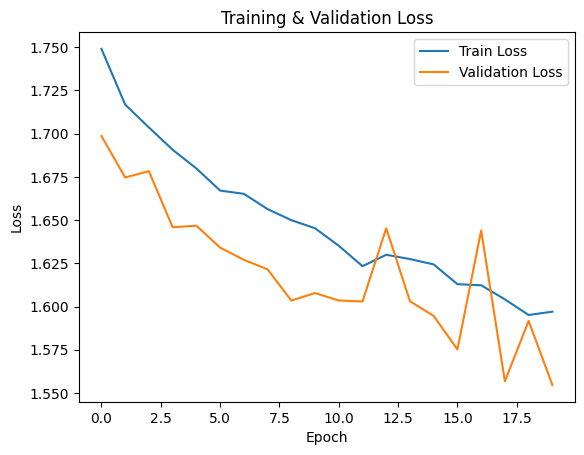

In [13]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")

plt.legend()
plt.show()

In [14]:
from sklearn.metrics import accuracy_score, recall_score

model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y.numpy())

acc = accuracy_score(all_true, all_preds)
uar = recall_score(all_true, all_preds, average="macro")

print("Test Accuracy:", acc)
print("Test UAR:", uar)

Test Accuracy: 0.2955665024630542
Test UAR: 0.27027027027027023
